# Week 03 - Customer Churn Prediction

## Objective

The goal of this project is to analyze customer churn data, understand the factors affecting churn, and build machine learning models to predict whether a customer is likely to leave the company.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### Import Libraries

- **Pandas** is used for loading and analyzing data.
- **NumPy** is used for numerical operations.
- **Matplotlib** and **Seaborn** are used to create visualizations.

In [3]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Dataset Preview

The first five rows help us understand the structure of the dataset and the available features.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Dataset Information

This shows the number of rows, columns, data types, and missing values.

In [6]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


### Statistical Summary

This provides statistical information such as mean, minimum, maximum, and quartiles for numerical columns.

In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Missing Values

This checks whether the dataset contains any missing values.

In [8]:
df.shape

(7043, 21)

In [9]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [10]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [11]:
df["TotalCharges"].head(10)

0      29.85
1     1889.5
2     108.15
3    1840.75
4     151.65
5      820.5
6     1949.4
7      301.9
8    3046.05
9    3487.95
Name: TotalCharges, dtype: object

In [16]:
(df["TotalCharges"] == " ").sum()

11

### TotalCharges Column

The `TotalCharges` column is stored as an object because it contains a few blank values. These blank values need to be handled before converting the column to a numeric data type.

In [10]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors='coerce')

In [18]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [19]:
df["TotalCharges"] = df["TotalCharges"].fillna(df["TotalCharges"].median())

### Handling Missing Values

The missing values in the `TotalCharges` column were replaced with the median because it is a numerical feature and the median is less affected by extreme values.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Churn Distribution

This chart shows the number of customers who stayed and those who left the company.

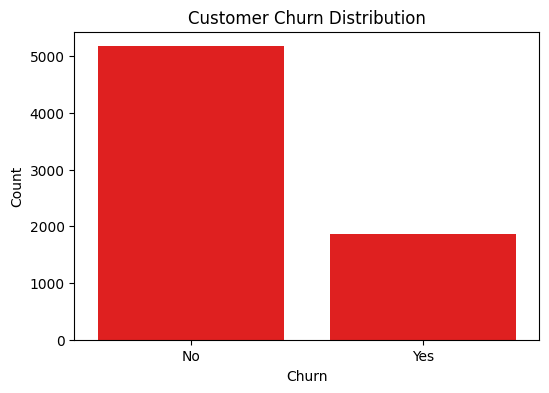

In [26]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df, color="red")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Observation

- Most customers did not churn.
- The number of customers who stayed is much higher than those who left.
- This indicates that the dataset is slightly imbalanced.

## Contract Type vs Churn

This chart compares customer churn across different contract types.

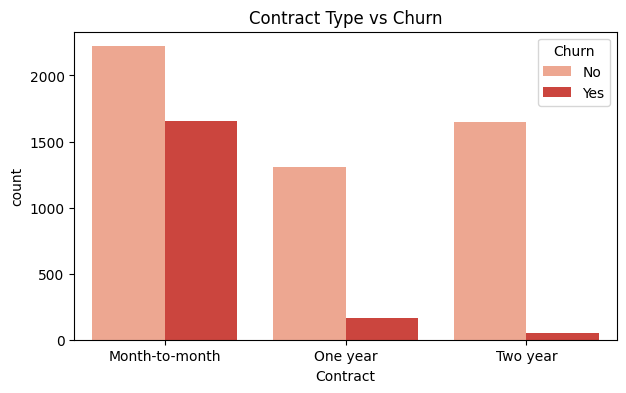

In [27]:
plt.figure(figsize=(7,4))
sns.countplot(x="Contract", hue="Churn", data=df, palette="Reds")

plt.title("Contract Type vs Churn")

plt.show()

### Observation

- Customers with month-to-month contracts have the highest churn.
- One-year and two-year contract customers are more likely to stay.
- Longer contracts are associated with lower churn.

## Tenure Distribution

This histogram shows how long customers stayed with the company.

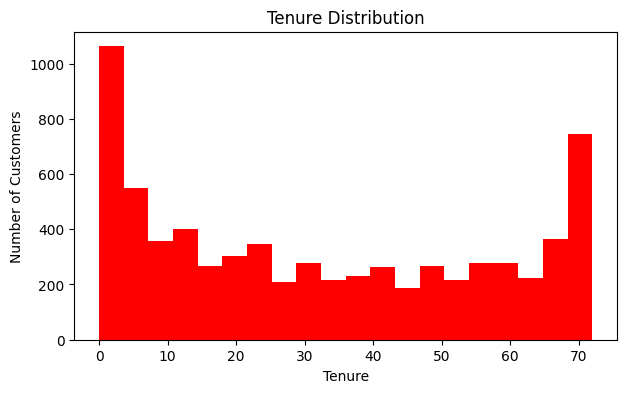

In [28]:
plt.figure(figsize=(7,4))
plt.hist(df["tenure"], bins=20, color="red")

plt.title("Tenure Distribution")
plt.xlabel("Tenure")
plt.ylabel("Number of Customers")

plt.show()

### Observation

- Many customers are either new or have stayed for a long time.
- Fewer customers fall in the middle tenure range.
- Customer loyalty tends to increase with longer tenure.

## Monthly Charges vs Churn

This boxplot compares monthly charges for customers who stayed and those who churned.

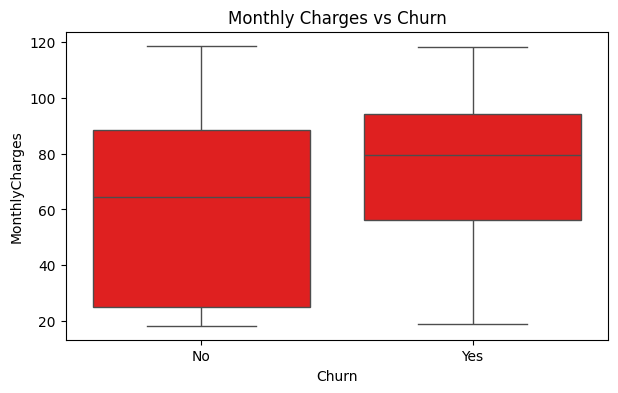

In [29]:
plt.figure(figsize=(7,4))
sns.boxplot(x="Churn", y="MonthlyCharges", data=df, color="red")

plt.title("Monthly Charges vs Churn")

plt.show()

### Observation

- Customers who churn generally have higher monthly charges.
- Customers with lower monthly charges are more likely to stay.
- Monthly charges appear to influence customer churn.

In [25]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

## Class Imbalance

The dataset contains more customers who stayed than customers who churned. This indicates a class imbalance that should be considered during model training.

## EDA Summary

- Most customers remained with the company.
- Month-to-month contracts have the highest churn rate.
- Customers with longer tenure are less likely to leave.
- Higher monthly charges are associated with a greater chance of churn.
- Contract type, tenure, and monthly charges appear to be the most important factors affecting customer churn.

## Preparing Data for Machine Learning

The `Churn` column is the target variable. The remaining columns will be used as features to predict customer churn.

In [11]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [12]:
X = X.drop("customerID", axis=1)

### Removing Customer ID

`customerID` is an identifier rather than a meaningful predictive feature, so it is removed before model training.

In [13]:
X = pd.get_dummies(X, drop_first=True)

In [14]:
X.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False


In [15]:
X.shape

(7043, 30)

### Encoding Categorical Variables

Categorical features were converted into numerical form using one-hot encoding so that they can be used by machine learning models.

In [16]:
y = y.map({"No": 0, "Yes": 1})

In [17]:
y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## Train-Test Split

The dataset is divided into training and testing sets. The model will learn from the training data and its performance will be evaluated on unseen test data.

In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Decision Tree Classifier

A Decision Tree makes predictions by splitting the data based on important features. It is easy to interpret and can show which features are most influential.

In [19]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [20]:
y_pred_dt = dt_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score, classification_report

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.794180269694819

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



## Logistic Regression

Logistic Regression is a classification algorithm used to predict the probability of a customer churning or staying.

In [23]:
X_train.isnull().sum().sort_values(ascending=False).head(10)

TotalCharges                             8
SeniorCitizen                            0
DeviceProtection_No internet service     0
PaymentMethod_Electronic check           0
PaymentMethod_Credit card (automatic)    0
PaperlessBilling_Yes                     0
Contract_Two year                        0
Contract_One year                        0
StreamingMovies_Yes                      0
StreamingMovies_No internet service      0
dtype: int64

In [24]:
X["TotalCharges"] = X["TotalCharges"].fillna(X["TotalCharges"].median())

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [26]:
X_train.isnull().sum().sum()

0

### Handling Missing Values

A few missing values were found in `TotalCharges`. They were replaced with the median value before model training to ensure the machine learning models could process the data.

In [27]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

c:\Users\computer lab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [28]:
y_pred_lr = lr_model.predict(X_test)

## Logistic Regression Predictions

The trained Logistic Regression model is used to predict whether customers in the test set will churn.

In [29]:
from sklearn.metrics import accuracy_score, classification_report

lr_accuracy = accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", lr_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8041163946061036

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.65      0.56      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.74      1409
weighted avg       0.80      0.80      0.80      1409



In [30]:
y_pred_dt = dt_model.predict(X_test)

dt_accuracy = accuracy_score(y_test, y_pred_dt)

print("Decision Tree Accuracy:", dt_accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.794180269694819

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.63      0.55      0.58       374

    accuracy                           0.79      1409
   macro avg       0.74      0.71      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [31]:
print("Decision Tree Accuracy:", dt_accuracy)
print("Logistic Regression Accuracy:", lr_accuracy)

Decision Tree Accuracy: 0.794180269694819
Logistic Regression Accuracy: 0.8041163946061036


## Model Comparison

Both models were evaluated on the same test data. Their accuracy and classification metrics were compared to determine which model performed better.

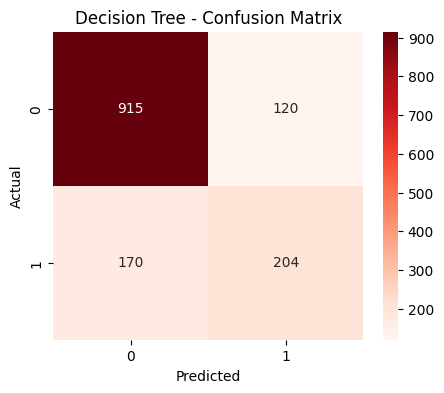

In [32]:
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Reds")

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

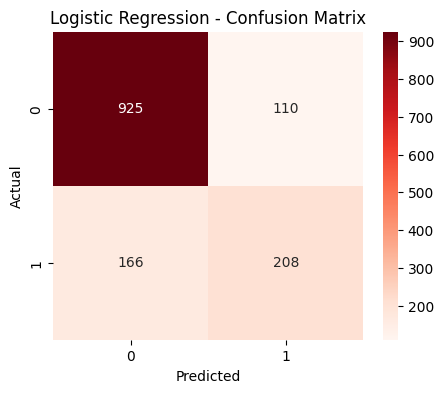

In [33]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Reds")

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### Class Imbalance

The target variable is imbalanced because the number of customers who did not churn is considerably higher than the number of customers who churned.

This means that a model could achieve relatively high accuracy by mostly predicting the majority class. Therefore, accuracy should be considered together with precision, recall, F1-score, and the confusion matrix.

For this project, the class imbalance was identified and considered during model evaluation.

### Model Comparison

The Decision Tree and Logistic Regression models were trained to predict whether a customer is likely to churn.

Both models achieved reasonable predictive performance. The Decision Tree is useful because it can capture non-linear relationships and provides feature importance scores, making it easier to identify important features. Logistic Regression provides a simpler and more interpretable baseline model.

The better-performing model can be selected based on the evaluation metrics, but accuracy alone should not be the only consideration because the dataset contains more non-churning customers than churning customers.

### Confusion Matrix

The confusion matrix shows how many customers were correctly and incorrectly classified as churn or non-churn.

In [34]:
feature_importance = pd.Series(
    dt_model.feature_importances_,
    index=X.columns
)

feature_importance = feature_importance.sort_values(
    ascending=False
)

### Confusion Matrix Observation

The confusion matrices show that both models correctly classify most non-churning customers.

For the Decision Tree, 204 churned customers were correctly identified, while 170 churned customers were incorrectly classified as non-churning.

For Logistic Regression, 208 churned customers were correctly identified, while 166 churned customers were incorrectly classified as non-churning.

This shows that Logistic Regression identifies slightly more actual churners in this test set, while both models have similar overall performance.

In [35]:
feature_importance.head(3)

tenure                         0.421435
InternetService_Fiber optic    0.357542
TotalCharges                   0.047129
dtype: float64

### Top 3 Features Driving Customer Churn

According to the Decision Tree feature importance scores, the top three features are:

1. **Tenure** – Tenure has the highest importance, suggesting that the length of time a customer has stayed with the company is strongly associated with churn predictions.
2. **Internet Service - Fiber Optic** – Fiber optic service is the second most important feature in the model, indicating that this customer segment has a notable relationship with churn.
3. **Total Charges** – Total charges are the third most important feature, suggesting that the overall amount paid by a customer also contributes to churn predictions.

These features are important for the model's predictions, but feature importance does not necessarily mean that they directly cause customer churn.

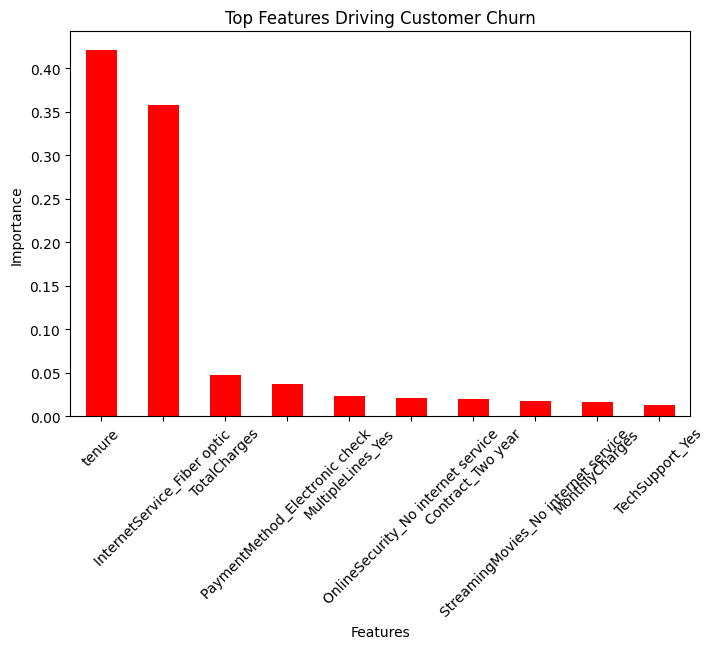

In [36]:
plt.figure(figsize=(8,5))

feature_importance.head(10).plot(
    kind="bar",
    color="red"
)

plt.title("Top Features Driving Customer Churn")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.xticks(rotation=45)
plt.show()

## Business Summary

Customer churn is an important business problem because losing existing customers can reduce recurring revenue and increase the cost of acquiring new customers. Our analysis shows that customer tenure, fiber optic internet service, and total charges are among the most important features used by the Decision Tree to predict churn. Customers with shorter tenure appear to be an important segment to monitor, while fiber optic customers also show a strong relationship with churn predictions. The models can help the company identify customers who may be at higher risk of leaving so that targeted retention offers or improved customer support can be provided. Overall, using predictive modeling can help the business take action before customers actually churn.

## Conclusion

In this project, we explored the Telco Customer Churn dataset, performed exploratory data analysis, handled categorical variables and missing values, and identified class imbalance in the target variable. We trained both a Decision Tree Classifier and a Logistic Regression model to predict customer churn. The Decision Tree feature importance showed that tenure, fiber optic internet service, and total charges were the three most important features for its predictions. The results demonstrate how machine learning can help businesses identify customers who may be at higher risk of churn and support data-driven retention strategies.